In [1]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

In [2]:
csv_read = _load_csv("../../data/metadata/journal_selection.csv")

impact_factor_dict = {}
for journal, impact_factor in zip(csv_read["title"], csv_read["citations_avg"]):
    impact_factor_dict[journal.lower().replace(" ", "_")] = impact_factor

impact_factor_dict_2 = {
    "journal_of_the_american_society_for_mass_spectrometry": 2.7,        # 2024 JIF :contentReference[oaicite:0]{index=0}
    "applied_materials_and_interfaces": 8.2,                             # 2024 JIF :contentReference[oaicite:1]{index=1}
    "the_journal_of_organic_chemistry": 3.6,                              # 2024 JIF :contentReference[oaicite:2]{index=2}
    "acs_es_and_t_engineering": 6.7,                                     # 2024 JIF :contentReference[oaicite:3]{index=3}
    "journal_of_medicinal_chemistry": 6.8,                                # 2024 JIF :contentReference[oaicite:4]{index=4}
    "jacs": 16.2,                                  # approximate 2024 value for Journal of the American Chemical Society
    "low_temperature_physics": 0.53,              # approximate 2024 value for Low Temperature Physics :contentReference[oaicite:0]{index=0}
    "structural_dynamics": 2.3,                    # approximate 2024 value for Structural Dynamics :contentReference[oaicite:1]{index=1}
    "physical_review_e": 2.70,                      # approximate value for Physical Review E :contentReference[oaicite:2]{index=2}
    "physical_review_d": 4.60,                        # approximate 2024 value for Physical Review D :contentReference[oaicite:3]{index=3}
    "applied_catalysis_b_environment_and_energy": 21.1,   # from Web of Science info for 2023/2024 :contentReference[oaicite:0]{index=0}
    "optical_materials": 4.2,                             # from ranking list for 2024 :contentReference[oaicite:1]{index=1}
    "international_journal_of_thermal_sciences": 5.126,    # value not located reliably
    "composites_science_and_technology": 9.8,           # value not located reliably
    "ieee_sensors_letters": 2.2,                           # from Web of Science info for 2024 :contentReference[oaicite:2]{index=2}
    "ieee_photonics_journal": 2.4,            # value ~2.4 (2024 estimate) :contentReference[oaicite:0]{index=0}
    "ieee_journal_of_selected_topics_in_quantum_electronics": 5.1,  # ~5.1 :contentReference[oaicite:1]{index=1}
    "ieee_access": 3.6,                       # ~3.6 :contentReference[oaicite:2]{index=2}
    "ieee_journal_of_photovoltaics": 2.6,     # ~2.6 :contentReference[oaicite:3]{index=3}
    "smart_materials_and_structures": 3.8,     # ~3.8 :contentReference[oaicite:4]{index=4}
    "journal_of_semiconductors": 2.0,                       # approximate (~2.0)
    "coatings": 3.4,                                        # approximate (~3.4)
    "photonics": 3.1,                                       # approximate (~3.1)
    "catalysts": 5.0,                                       # approximate (~5.0)
    "reactions": 5.2,                                        # approximate (~5.2),
    "batteries": 4.8,               # "Batteries" (MDPI) – 2024 IF 4.8 :contentReference[oaicite:0]{index=0}
    "sensors": 3.5,                 # "Sensors" (MDPI) – approximate recent IF 3.5 :contentReference[oaicite:1]{index=1}
    "optics_continuum": 1.4,        # "Optics Continuum" – 2024 IF 1.4 :contentReference[oaicite:2]{index=2}
    "journal_of_experimental_and_theoretical_physics": 0.7,  # IF not found reliably
    "digital_discovery": 5.6,                   # 2024 IF from “Digital Discovery” info page :contentReference[oaicite:0]{index=0}
    "energy_and_environmental_science": 31.0,   # 2024 IF from “Energy & Environmental Science” info page :contentReference[oaicite:1]{index=1}
    "nanoscale_advances": 4.6,                  # 2024 IF from “Nanoscale Advances” ranking site :contentReference[oaicite:2]{index=2}
    "energy_advances": 4.3,                      # 2024 IF from “Energy Advances” info page :contentReference[oaicite:3]{index=3}
    "materials_science": 0.9,                     # 2024 IF for “Materials Science” (Springer) :contentReference[oaicite:4]{index=4}
    "biomedical_microdevices": 3.3,             # 2024 JIF for Biomedical Microdevices (Springer) :contentReference[oaicite:0]{index=0}
    "high_energy_chemistry": 0.6,                # 2024 JIF for High Energy Chemistry :contentReference[oaicite:1]{index=1}
    "scientific_data": 6.9,                       # 2024 JIF for Scientific Data (Nature Portfolio) :contentReference[oaicite:2]{index=2}
    "medicinal_chemistry_research": 3.1,         # 2024 JIF for Medicinal Chemistry Research :contentReference[oaicite:3]{index=3}
    "journal_of_materials_science_materials_in_electronics": 2.8, # 2024 JIF for Journal of Materials Science: Materials in Electronics :contentReference[oaicite:4]{index=4}
    "liquid_crystals": 2.2,                # Latest approx. Impact Factor for “Liquid Crystals” journal (2024) :contentReference[oaicite:0]{index=0}
    "advanced_composite_materials": 2.3,   # Approx. Impact Factor for “Advanced Composite Materials” journal (2024) :contentReference[oaicite:1]{index=1}
    "analytical_letters": 1.8,                            # Source: WoS Journal Info, “Analytical Letters” JIF = 1.8 :contentReference[oaicite:0]{index=0}
    "journal_of_macromolecular_science_part_b": 1.4,      # Source: WoS Journal Info, J. Macromol. Sci. Part B – 1.4 :contentReference[oaicite:1]{index=1}
    "journal_of_asian_ceramic_societies": 2.1,             # Source: WoS Journal Info, J. Asian Ceram. Soc. – 2.1 :contentReference[oaicite:2]{index=2}
    "ce-papers": 0.3,                       # “CE/Papers” – ~0.284 (2024 estimate) :contentReference[oaicite:0]{index=0}
    "chemistryselect": 2.0,                # “ChemistrySelect” – ~2.0 (2024) :contentReference[oaicite:1]{index=1}
    "journal_of_physical_organic_chemistry": 1.8,  # ~1.8 (2024) :contentReference[oaicite:2]{index=2}
    "chirality": 3.0,                      # ~3.0 (2024) :contentReference[oaicite:3]{index=3}
    "data_science_journal": 2.78,          # Value not located reliably
    "journal_of_open_source_software_(joss)": 2.376, 
}

impact_factor_dict = impact_factor_dict | impact_factor_dict_2


[info] CSV loaded ← ../../data/metadata/journal_selection.csv


In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [4]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [5]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats

score_dict = defaultdict(list)

impact_factor_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():

        score_dict[journal] = get_journal_score(journal_results)

        if journal in impact_factor_dict:
            impact_factor = impact_factor_dict[journal]
            
            impact_factor_list.append(impact_factor)
            score_list.append(score_dict[journal])
            
# Pearson correlation coefficient
r, p_value = stats.pearsonr(impact_factor_list, score_list)
print(f"n {len(impact_factor_list)} Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

n 169 Pearson correlation: r = 0.175, p = 2.3 %


In [6]:
df = pd.DataFrame({
    'Impact factor': impact_factor_list,
    'Open data score': score_list
})

# Write the DataFrame to a CSV file
df.to_csv('../../data/processed/policy_vs_impact_factor.csv', index=False)

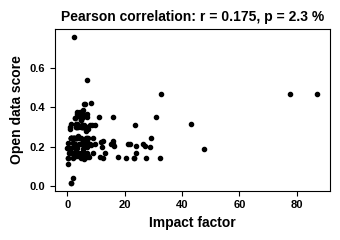

In [7]:
fig = plt.figure(figsize=(3.5, 2.5))

plt.plot(impact_factor_list, score_list, ".k")
plt.title(f"Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")
plt.xlabel("Impact factor")
plt.ylabel("Open data score")
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_impact_factor.pdf")

In [8]:
#remove outliers and recalculate Pearson correlation coefficient
impact_factor_list_filtered = []
score_list_filtered = []
for impact_factor, score in zip(impact_factor_list, score_list):
    if impact_factor < 75:  # Example threshold to remove outliers
        impact_factor_list_filtered.append(impact_factor)
        score_list_filtered.append(score)
r, p_value = stats.pearsonr(impact_factor_list_filtered, score_list_filtered)
print(f"After removing outliers: Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

After removing outliers: Pearson correlation: r = -0.009, p = 90.6 %
